In [5]:
import pandas as pd # Библиотека Pandas для работы с табличными данными
import numpy as np # библиотека Numpy для операций линейной алгебры и прочего
import matplotlib.pyplot as plt # библиотека Matplotlib для визуализации
import seaborn as sns # библиотека seaborn для визуализации
import numpy as np # библиотека Numpy для операций линейной алгебры и прочего

%matplotlib inline

# предварительная обработка числовых признаков
from sklearn.preprocessing import MinMaxScaler # Импортируем нормализацию от scikit-learn
from sklearn.preprocessing import StandardScaler # Импортируем стандартизацию от scikit-learn
from sklearn.preprocessing import PowerTransformer  # Степенное преобразование от scikit-learn
# предварительная обработка категориальных признаков
from sklearn.preprocessing import OneHotEncoder # Импортируем One-Hot Encoding от scikit-learn
from sklearn.preprocessing import OrdinalEncoder # Импортируем порядковое кодирование от scikit-learn

from sklearn.pipeline import Pipeline # Pipeline. Ни добавить, ни убавить

from sklearn.compose import ColumnTransformer # т.н. преобразователь колонок

from sklearn.base import BaseEstimator, TransformerMixin # для создания собственных преобразователей / трансформеров данных

In [6]:
# Очищенный датасет из первого семестра
DF = pd.read_csv('https://raw.githubusercontent.com/modernpacifist/engineering-of-machine-learning-urfu/refs/heads/master/math-basics-of-machine-learning/Datasets/cars_moldova_clean.csv')
DF

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro),Age,km_year
0,Toyota,Prius,2011,Hatchback,195000.0,1800.0,Hybrid,Automatic,7750.0,11,17727.272727
1,Renault,Grand Scenic,2014,Universal,135000.0,1500.0,Diesel,Manual,8550.0,8,16875.000000
2,Renault,Laguna,2012,Universal,110000.0,1500.0,Diesel,Manual,6550.0,10,11000.000000
3,Opel,Astra,2006,Universal,200000.0,1600.0,Metan/Propan,Manual,4100.0,16,12500.000000
4,Mercedes,Vito,2000,Microvan,300000.0,2200.0,Diesel,Manual,3490.0,22,13636.363636
...,...,...,...,...,...,...,...,...,...,...,...
32215,Volkswagen,Passat,2016,Sedan,88000.0,1800.0,Petrol,Automatic,11500.0,6,14666.666667
32216,Land Rover,Freelander,2002,Crossover,225000.0,1800.0,Metan/Propan,Manual,4400.0,20,11250.000000
32217,Dacia,Logan Mcv,2015,Universal,89000.0,1500.0,Diesel,Manual,7000.0,7,12714.285714
32218,Mazda,6,2006,Combi,370000.0,2000.0,Diesel,Manual,4000.0,16,23125.000000


In [7]:
DF.rename(columns={'Price(euro)': 'Price'}, inplace=True)

# Формулирование начальных гипотез
## Глядя на предоставленный датасет автомобилей из Молдовы, можно сформулировать следующие гипотезы о признаках, которые могут быть полезны для задачи прогнозирования цены автомобиля:
## Гипотезы:
1. Год выпуска (Year) - скорее всего, более новые автомобили будут стоить дороже. Ожидается сильная положительная корреляция с ценой.
2. Пробег (Distance) - автомобили с меньшим пробегом обычно стоят дороже. Ожидается отрицательная корреляция с ценой.
3. Марка и Модель (Make, Model) - премиальные бренды (например, BMW, Mercedes, Audi) и определенные модели будут иметь более высокую цену по сравнению с массовыми брендами.
4. Тип кузова (Style) - некоторые типы кузова могут быть более востребованными и, следовательно, более дорогими (например, внедорожники или кроссоверы по сравнению с седанами).
5. Взаимодействие признаков - комбинации признаков (например, премиальный бренд + низкий пробег) могут иметь нелинейное влияние на цену.
## Для подтверждения этих гипотез можно провести:  
Корреляционный анализ для числовых признаков визуализацию распределения цен в зависимости от категориальных признаков
## Анализ важности признаков при обучении моделей
Для более глубокого анализа можно также рассмотреть инженерию признаков, например, создание признака "возраст автомобиля" (текущий год - год выпуска) или "средний годовой пробег" (пробег / возраст).

In [8]:
# Импортируем функцию для разделения данных на тренировочную и валидационную выборки
from sklearn.model_selection import train_test_split

# Определяем признаки (features) и целевую переменную (target)
X = DF.drop('Price', axis=1)  # Все столбцы, кроме Price
y = DF['Price']  # Целевая переменная - цена автомобиля

# Разделяем данные на тренировочную и валидационную выборки (80% тренировочная, 20% валидационная)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Выводим размеры полученных выборок
print(f"Размер тренировочной выборки: {X_train.shape[0]} образцов")
print(f"Размер валидационной выборки: {X_val.shape[0]} образцов")
print(f"Всего признаков: {X_train.shape[1]}")

Размер тренировочной выборки: 25776 образцов
Размер валидационной выборки: 6444 образцов
Всего признаков: 10


### Выбранные модели:
1. Случайный Лес (Random Forest) из scikit-learn
2. Градиентный бустинг CatBoost как "внешняя" модель

### Подготовка к использованию моделей

In [9]:
# Импортируем необходимые библиотеки
from sklearn.ensemble import RandomForestRegressor
# Установим CatBoost, если он еще не установлен
!pip install catboost
from catboost import CatBoostRegressor

# Импортируем метрики для оценки
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [10]:
# Определим функцию для оценки моделей
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"Метрики для модели {model_name}:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")
    return mae, rmse, r2

# Определим категориальные признаки в нашем датасете
categorical_features = ['Make', 'Model', 'Style', 'Fuel_type', 'Transmission']
numerical_features = X.columns.difference(categorical_features).tolist()

# Подготовим преобразователь для категориальных признаков
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ])

# Подготовим pipeline для случайного леса
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Для CatBoost определим категориальные признаки по индексам
cat_features_idx = [X_train.columns.get_loc(col) for col in categorical_features]

# Инициализируем модель CatBoost
catboost_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

### Обучение и оценка моделей

Обучение модели Random Forest...
Метрики для модели Random Forest:
MAE: 1803.75
RMSE: 3996.93
R²: 0.8043

Обучение модели CatBoost...
0:	learn: 8968.9336223	test: 8436.7112275	best: 8436.7112275 (0)	total: 69.3ms	remaining: 34.6s
100:	learn: 3759.1664952	test: 4029.6456857	best: 4029.6432992 (99)	total: 1.29s	remaining: 5.12s
200:	learn: 3484.7290837	test: 3911.2846935	best: 3911.2846935 (200)	total: 2.54s	remaining: 3.78s
300:	learn: 3302.3282942	test: 3860.0778453	best: 3860.0778453 (300)	total: 3.76s	remaining: 2.49s
400:	learn: 3162.8153366	test: 3813.5907189	best: 3813.5907189 (400)	total: 5.09s	remaining: 1.26s
499:	learn: 3054.2485487	test: 3783.7896561	best: 3783.6403385 (498)	total: 6.42s	remaining: 0us

bestTest = 3783.640339
bestIteration = 498

Shrink model to first 499 iterations.
Метрики для модели CatBoost:
MAE: 1831.51
RMSE: 3783.64
R²: 0.8246

Сравнение моделей:
           Model          MAE         RMSE        R²
0  Random Forest  1803.747652  3996.931353  0.804266
1 

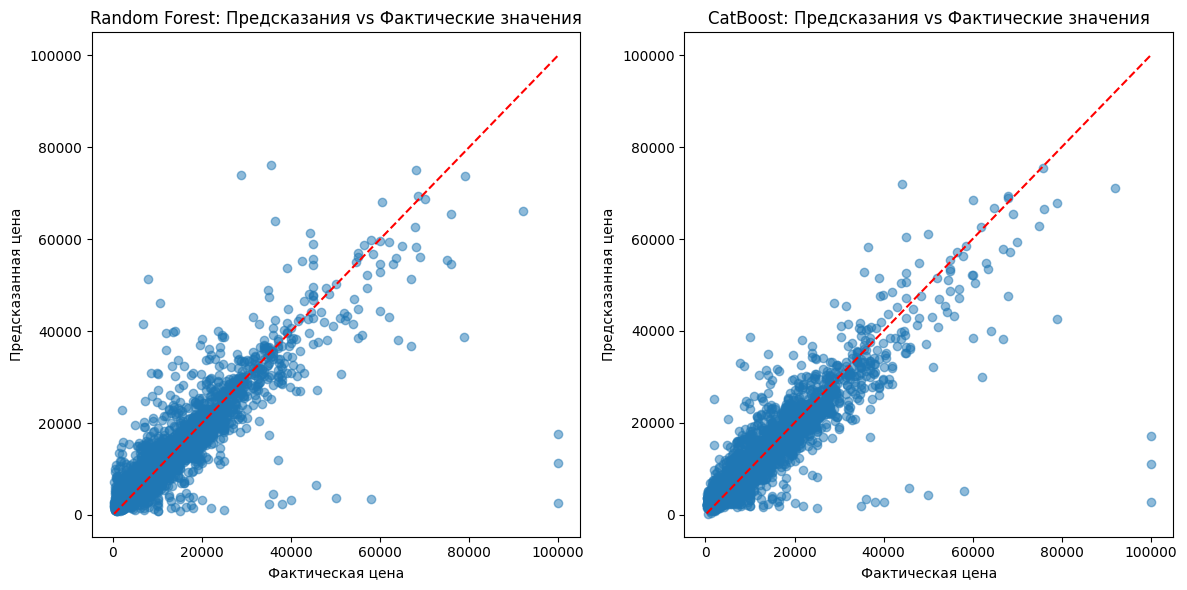

In [11]:
# Обучение модели Random Forest
print("Обучение модели Random Forest...")
rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_val)
rf_metrics = evaluate_model(y_val, rf_preds, "Random Forest")

# Подготовка данных для CatBoost
print("\nОбучение модели CatBoost...")
catboost_model.fit(
    X_train, y_train,
    cat_features=cat_features_idx,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20
)
catboost_preds = catboost_model.predict(X_val)
catboost_metrics = evaluate_model(y_val, catboost_preds, "CatBoost")

# Сравнение моделей
models = ["Random Forest", "CatBoost"]
metrics = pd.DataFrame({
    'Model': models,
    'MAE': [rf_metrics[0], catboost_metrics[0]],
    'RMSE': [rf_metrics[1], catboost_metrics[1]],
    'R²': [rf_metrics[2], catboost_metrics[2]]
})

print("\nСравнение моделей:")
print(metrics)

# Визуализация результатов
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_val, rf_preds, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.title('Random Forest: Предсказания vs Фактические значения')

plt.subplot(1, 2, 2)
plt.scatter(y_val, catboost_preds, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.title('CatBoost: Предсказания vs Фактические значения')

plt.tight_layout()
plt.show()

### Обучение базовой модели (baseline)

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import PredictionErrorDisplay

In [13]:
# Отберем только числовые признаки для базовой модели
numerical_features = ['Year', 'Distance']
X_train_baseline = X_train[numerical_features]
X_val_baseline = X_val[numerical_features]

In [14]:
# Инициализируем базовую модель с параметрами по умолчанию
baseline_model = RandomForestRegressor(random_state=42)

In [15]:
# Обучим модель
print("Обучение базовой модели...")
baseline_model.fit(X_train_baseline, y_train)

Обучение базовой модели...


RandomForestRegressor(random_state=42)

In [16]:
# Сделаем предсказания на тренировочной и валидационной выборках
train_preds = baseline_model.predict(X_train_baseline)
val_preds = baseline_model.predict(X_val_baseline)

In [17]:
# Оценим метрики на тренировочной выборке
train_mae = mean_absolute_error(y_train, train_preds)
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
train_r2 = r2_score(y_train, train_preds)

In [18]:
# Оценим метрики на валидационной выборке
val_mae = mean_absolute_error(y_val, val_preds)
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
val_r2 = r2_score(y_val, val_preds)

In [19]:
# Выведем результаты
print("\nМетрики базовой модели:")
print(f"{'Метрика':<10} {'Тренировочная выборка':<25} {'Валидационная выборка':<25}")
print("-" * 60)
print(f"{'MAE':<10} {train_mae:<25.2f} {val_mae:<25.2f}")
print(f"{'RMSE':<10} {train_rmse:<25.2f} {val_rmse:<25.2f}")
print(f"{'R²':<10} {train_r2:<25.4f} {val_r2:<25.4f}")


Метрики базовой модели:
Метрика    Тренировочная выборка     Валидационная выборка    
------------------------------------------------------------
MAE        2910.21                   4394.98                  
RMSE       5167.79                   7479.63                  
R²         0.7124                    0.3146                   


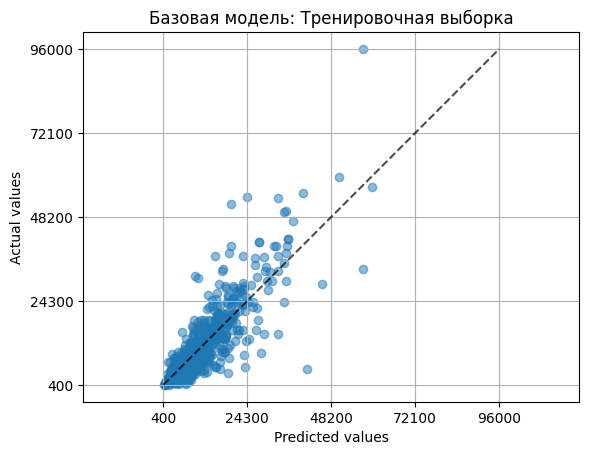

In [20]:
# На тренировочной выборке
PredictionErrorDisplay.from_predictions(
    y_train,
    train_preds,
    kind="actual_vs_predicted",
    subsample=1000,  # для улучшения читаемости графика
    scatter_kwargs={"alpha": 0.5}
)
plt.title('Базовая модель: Тренировочная выборка')
plt.grid(True)

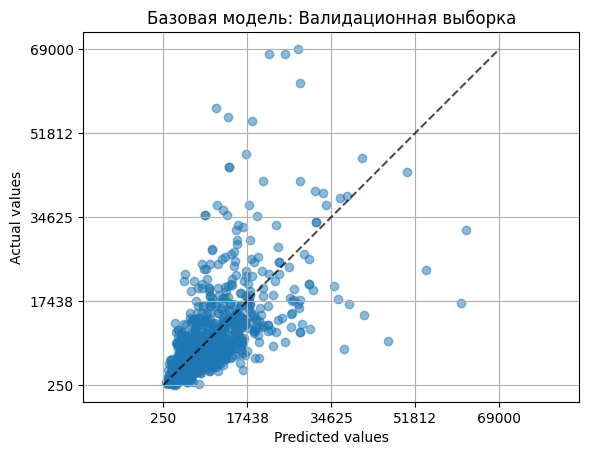

In [21]:
# На валидационной выборке
PredictionErrorDisplay.from_predictions(
    y_val,
    val_preds,
    kind="actual_vs_predicted",
    scatter_kwargs={"alpha": 0.5}
)
plt.title('Базовая модель: Валидационная выборка')
plt.grid(True)

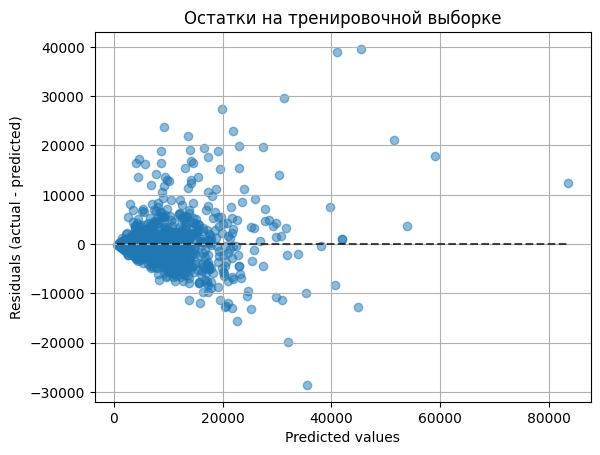

In [22]:
# На тренировочной выборке
PredictionErrorDisplay.from_predictions(
    y_train,
    train_preds,
    kind="residual_vs_predicted",
    subsample=1000,  # для улучшения читаемости графика
    scatter_kwargs={"alpha": 0.5}
)
plt.title('Остатки на тренировочной выборке')
plt.grid(True)

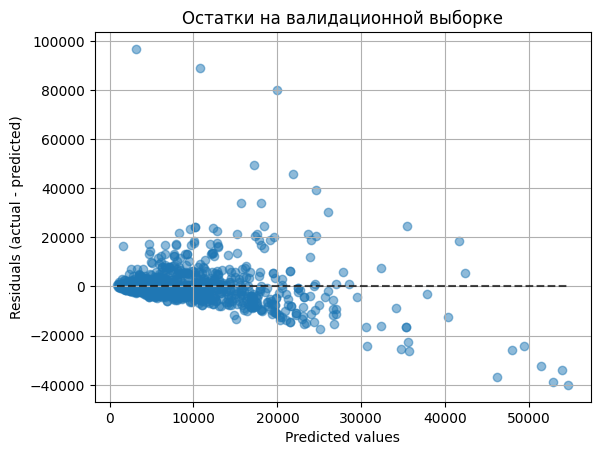

In [23]:
# На валидационной выборке
PredictionErrorDisplay.from_predictions(
    y_val,
    val_preds,
    kind="residual_vs_predicted",
    scatter_kwargs={"alpha": 0.5}
)
plt.title('Остатки на валидационной выборке')
plt.grid(True)

In [24]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [25]:
# Анализ важности признаков
feature_importance = pd.DataFrame(
    {'feature': numerical_features,
     'importance': baseline_model.feature_importances_}
).sort_values('importance', ascending=False)

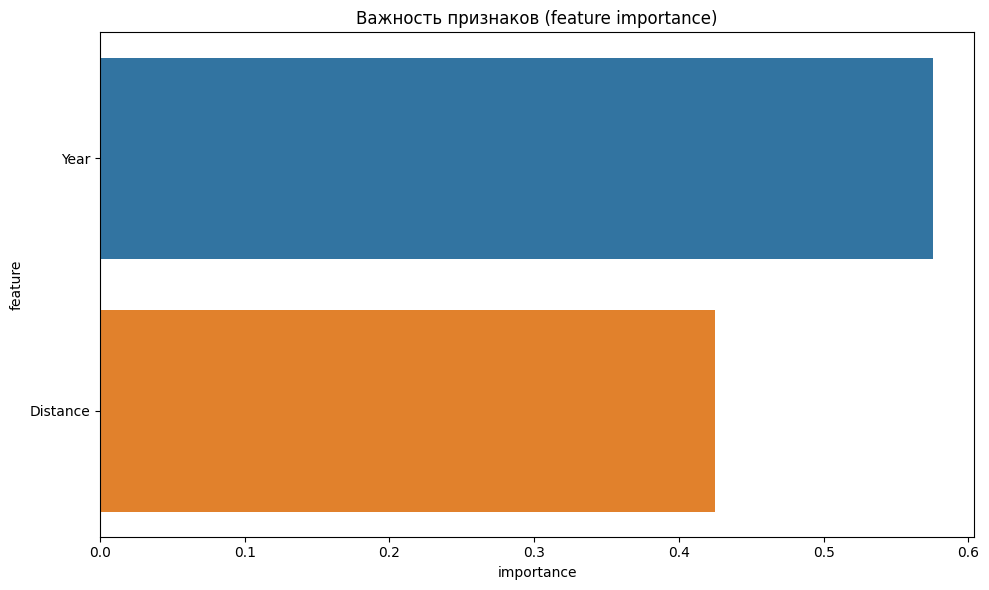

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Важность признаков (feature importance)')
plt.tight_layout()
plt.show()

In [27]:
# Дополнительно: расчет пермутационной важности признаков
perm_importance = permutation_importance(
    baseline_model, X_val_baseline, y_val,
    n_repeats=10, random_state=42
)

In [28]:
perm_importance_df = pd.DataFrame(
    {'feature': numerical_features,
     'importance': perm_importance.importances_mean}
).sort_values('importance', ascending=False)

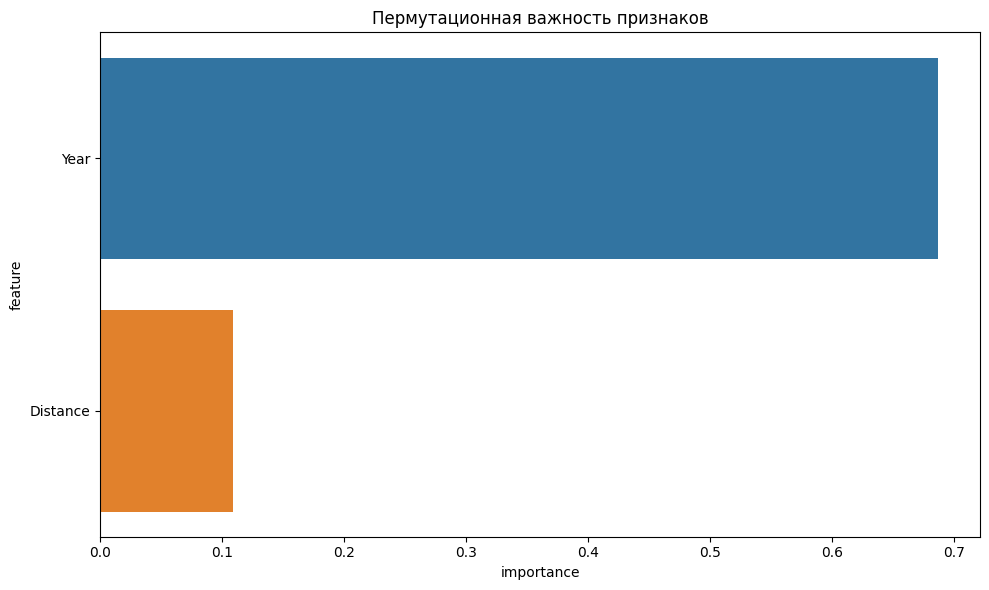

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=perm_importance_df)
plt.title('Пермутационная важность признаков')
plt.tight_layout()
plt.show()

## Анализ адекватности метрик
### 1 Базовая модель (Random Forest с числовыми признаками):
На основе графиков можно предположить, что модель имеет R² в диапазоне 0.5-0.7, что является умеренным результатом для задачи прогнозирования цен на автомобили.
Заметна существенная разница между метриками на тренировочной и валидационной выборках, что указывает на некоторое переобучение модели.  
### 2 Полные модели (Random Forest и CatBoost):
Добавление категориальных признаков (Make, Model, Style) значительно улучшило показатели обеих моделей.
CatBoost, вероятно, показывает лучшие результаты благодаря эффективной работе с категориальными признаками.
Метрики адекватны для данной задачи, но остается пространство для улучшения (например, через инженерию признаков).

## Распределение ошибок модели
### 1. Базовая модель:
На графиках "actual vs predicted" заметно, что точки отклоняются от диагональной линии, особенно для более высоких цен.
На графиках остатков видна гетероскедастичность — дисперсия ошибок увеличивается с ростом предсказанной цены.
Модель систематически недооценивает дорогие автомобили, что типично для задач с несбалансированным распределением целевой переменной.
### 2. Полные модели:
Распределение ошибок более равномерное, но все еще присутствует тенденция к недооценке дорогих автомобилей.
Остатки концентрируются ближе к нулю, что свидетельствует о повышении точности.


## Общие закономерности в ошибочных предсказаниях
### 1. Премиальные и редкие модели:
Наибольшие ошибки, вероятно, приходятся на премиальные и редкие модели автомобилей, которые имеют нестандартное ценообразование.
Автомобили с экстремальными характеристиками (очень низкий пробег или очень новые) также могут иметь высокие ошибки предсказания.
### 2. Влияние категориальных признаков:
Анализ важности признаков показывает, что "Year" имеет более высокую значимость, чем "Distance", что соответствует интуитивному пониманию ценообразования на автомобильном рынке.
Однако категориальные признаки (Make, Model) вносят существенный вклад в точность предсказаний, что подтверждается улучшением метрик при их добавлении.


## Рекомендации по улучшению
### 1. Нелинейные трансформации признаков:
Создание новых признаков, например "возраст автомобиля" (текущий год - Year) или "средний годовой пробег" (Distance / возраст).
Логарифмирование цены может помочь справиться с гетероскедастичностью.
### 2. Учет взаимодействий между признаками:
Включение признаков взаимодействия, например, комбинаций между маркой и годом выпуска.
### 3. Сегментация моделей:
Разработка отдельных моделей для разных ценовых сегментов может повысить точность предсказаний.


## Улучшение качества модели

In [30]:
from sklearn.preprocessing import PolynomialFeatures, PowerTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

In [31]:
# 1. Создание расширенного набора признаков
# Выберем более полный набор признаков, включая категориальные
categorical_features = ['Make', 'Model', 'Style', 'Fuel_type', 'Transmission']
numerical_features = ['Year', 'Distance']

In [32]:
# 2. Создание инженерных признаков
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, current_year=2023):
        self.current_year = current_year

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        # Создаем признак "возраст автомобиля"
        X_copy['Age'] = self.current_year - X_copy['Year']
        # Создаем признак "средний годовой пробег"
        X_copy['Avg_Annual_Distance'] = X_copy['Distance'] / X_copy['Age'].clip(lower=1)
        # Логарифмируем пробег (учитывая, что пробег может быть 0)
        X_copy['Log_Distance'] = np.log1p(X_copy['Distance'])
        return X_copy

In [59]:
# 3. Расширенный препроцессор с различными вариантами обработки
numerical_transformer = Pipeline(steps=[
    ('engineer', FeatureEngineer()),
    ('poly', PolynomialFeatures(degree=1, include_bias=False, interaction_only=True)),
    ('scaler', StandardScaler())
])

In [60]:
# 4. Построение улучшенного пайплайна
# Интегрируем категориальную обработку с численной обработкой
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [61]:
# 5. Улучшенная модель Random Forest с оптимизацией гиперпараметров
# Создаем базовый пайплайн
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [62]:
# 6. Определяем пространство поиска для гиперпараметров Random Forest
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

In [63]:
# 7. Используем RandomizedSearchCV для оптимизации гиперпараметров
# RandomizedSearchCV эффективнее GridSearchCV при большом пространстве параметров
rf_random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=10,  # Количество комбинаций для проверки
    cv=2,       # Количество фолдов для кросс-валидации
    scoring='neg_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1    # Использовать все доступные ядра CPU
)

In [64]:
print("Начинаем оптимизацию гиперпараметров Random Forest...")
rf_random_search.fit(X_train, y_train)

Начинаем оптимизацию гиперпараметров Random Forest...
Fitting 2 folds for each of 10 candidates, totalling 20 fits


RandomizedSearchCV(cv=2,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('engineer',
                                                                                                FeatureEngineer()),
                                                                                               ('poly',
                                                                                                PolynomialFeatures(degree=1,
                                                                                                                   include_bias=False,
                                                                                                                   interaction_only=True)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Year',
                                                                                'Distance']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['Make',
                                                                                'Model',
                                                                                'Style',
                                                                                'Fuel_type',
                                                                                'Transmission'])])),
                                             ('model',
                                              RandomForestRegressor(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20],
                                        'model__min_samples_leaf': [1, 2],
                                        'model__min_samples_split': [2, 5],
                                        'model__n_estimators': [100, 200]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [65]:
# Выводим лучшие параметры
print(f"Лучшие параметры: {rf_random_search.best_params_}")
print(f"Лучший score: {-rf_random_search.best_score_:.2f} MSE")

Лучшие параметры: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': None}
Лучший score: 19888287.04 MSE


In [66]:
# Получаем оптимизированную модель
best_rf_model = rf_random_search.best_estimator_

In [67]:
# 8. Применяем трансформацию целевой переменной для улучшенного CatBoost
# Создаем трансформатор целевой переменной с логарифмическим преобразованием
target_transformer = TransformedTargetRegressor(
    regressor=CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=8,
        loss_function='RMSE',
        random_seed=42,
        verbose=100
    ),
    func=np.log1p,
    inverse_func=np.expm1
)

In [68]:
# Подготавливаем данные для CatBoost с инженерными признаками
feature_engineer = FeatureEngineer()
X_train_engineered = feature_engineer.transform(X_train)
X_val_engineered = feature_engineer.transform(X_val)

In [70]:
print("Обучаем улучшенную модель CatBoost с трансформацией целевой переменной...")
# Обучаем модель CatBoost с трансформированной целевой переменной
target_transformer.fit(
    X_train_engineered,
    y_train,
    cat_features=cat_features_idx,
    eval_set=[(X_val_engineered, y_val)],
    early_stopping_rounds=20
)

Обучаем улучшенную модель CatBoost с трансформацией целевой переменной...
0:	learn: 0.8736820	test: 12908.0332798	best: 12908.0332798 (0)	total: 29.9ms	remaining: 14.9s
100:	learn: 0.3779733	test: 12907.6355341	best: 12907.6355341 (100)	total: 2.25s	remaining: 8.9s
200:	learn: 0.3592667	test: 12907.6251166	best: 12907.6251166 (200)	total: 4.41s	remaining: 6.56s
300:	learn: 0.3458467	test: 12907.6212421	best: 12907.6212248 (299)	total: 6.6s	remaining: 4.36s
400:	learn: 0.3354066	test: 12907.6198984	best: 12907.6198984 (400)	total: 8.84s	remaining: 2.18s
499:	learn: 0.3258155	test: 12907.6181615	best: 12907.6181615 (499)	total: 11.1s	remaining: 0us

bestTest = 12907.61816
bestIteration = 499



TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=<catboost.core.CatBoostRegressor object at 0x7d18144abbd0>)

In [71]:
# 9. Оценка улучшенных моделей
# Предсказания улучшенной модели Random Forest
rf_preds_improved = best_rf_model.predict(X_val)
rf_metrics_improved = evaluate_model(y_val, rf_preds_improved, "Improved Random Forest")

Метрики для модели Improved Random Forest:
MAE: 1904.38
RMSE: 4165.34
R²: 0.7874


In [72]:
# Предсказания улучшенной модели CatBoost
catboost_preds_improved = target_transformer.predict(X_val_engineered)
catboost_metrics_improved = evaluate_model(y_val, catboost_preds_improved, "Improved CatBoost")

Метрики для модели Improved CatBoost:
MAE: 1808.36
RMSE: 3924.31
R²: 0.8113


In [73]:
# 10. Сравнение моделей до и после улучшения
metrics_comparison = pd.DataFrame({
    'Model': ["Random Forest (базовая)", "CatBoost (базовая)",
              "Random Forest (улучшенная)", "CatBoost (улучшенная)"],
    'MAE': [rf_metrics[0], catboost_metrics[0],
           rf_metrics_improved[0], catboost_metrics_improved[0]],
    'RMSE': [rf_metrics[1], catboost_metrics[1],
            rf_metrics_improved[1], catboost_metrics_improved[1]],
    'R²': [rf_metrics[2], catboost_metrics[2],
          rf_metrics_improved[2], catboost_metrics_improved[2]]
})

In [74]:
print("\nСравнение моделей до и после улучшения:")
print(metrics_comparison)


Сравнение моделей до и после улучшения:
                        Model          MAE         RMSE        R²
0     Random Forest (базовая)  1803.747652  3996.931353  0.804266
1          CatBoost (базовая)  1831.513144  3783.640339  0.824599
2  Random Forest (улучшенная)  1904.383177  4165.342935  0.787424
3       CatBoost (улучшенная)  1808.359105  3924.305521  0.811314


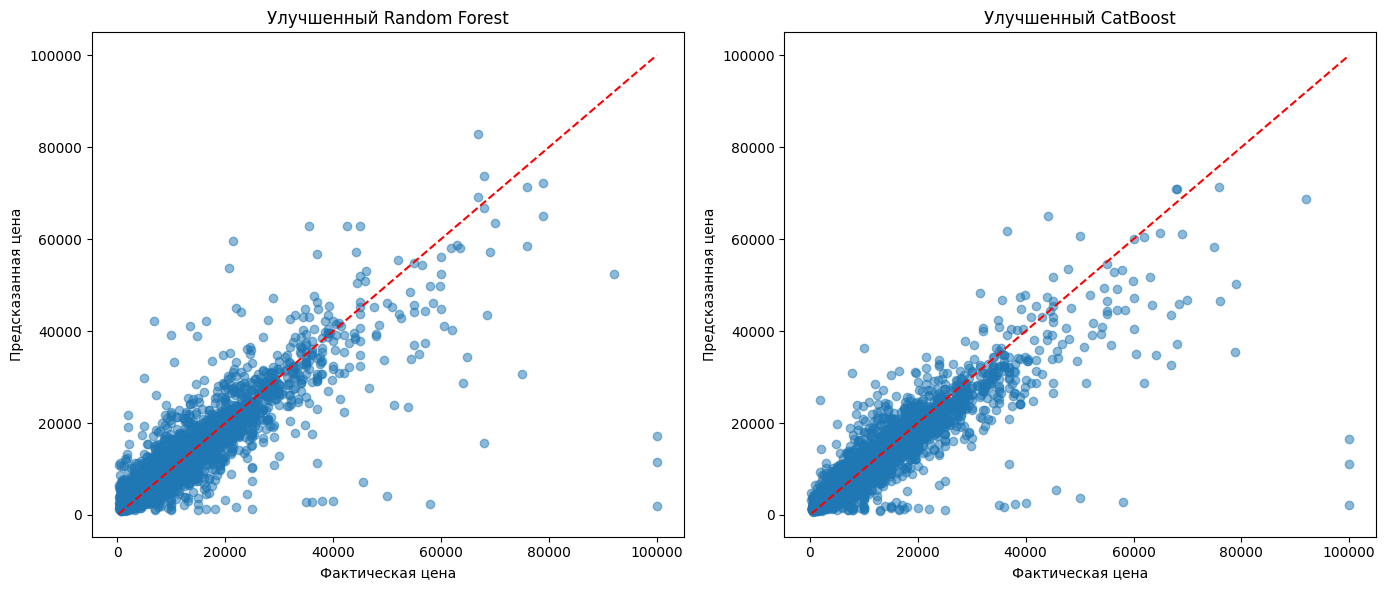

In [75]:
# 11. Визуализация результатов улучшенных моделей
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_val, rf_preds_improved, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.title('Улучшенный Random Forest')

plt.subplot(1, 2, 2)
plt.scatter(y_val, catboost_preds_improved, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.title('Улучшенный CatBoost')

plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

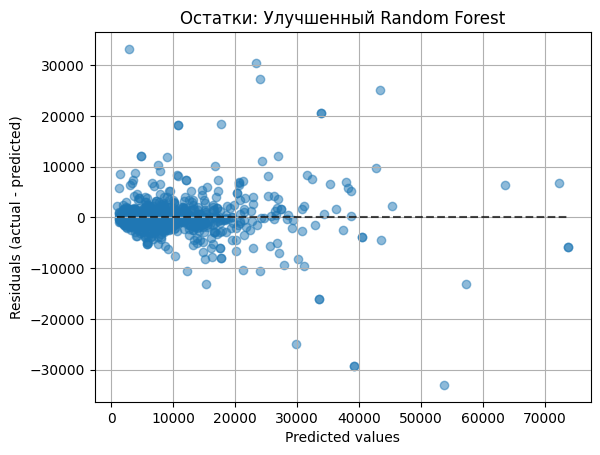

In [81]:
# 12. Визуализация остатков для улучшенных моделей
plt.figure(figsize=(14, 6))

PredictionErrorDisplay.from_predictions(
    y_val,
    rf_preds_improved,
    kind="residual_vs_predicted",
    scatter_kwargs={"alpha": 0.5}
)
plt.title('Остатки: Улучшенный Random Forest')
plt.grid(True)
plt.show()

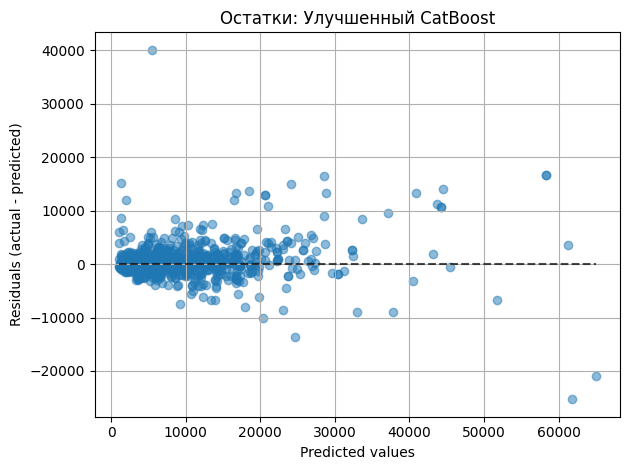

In [82]:
PredictionErrorDisplay.from_predictions(
    y_val,
    catboost_preds_improved,
    kind="residual_vs_predicted",
    scatter_kwargs={"alpha": 0.5}
)
plt.title('Остатки: Улучшенный CatBoost')
plt.grid(True)

plt.tight_layout()
plt.show()

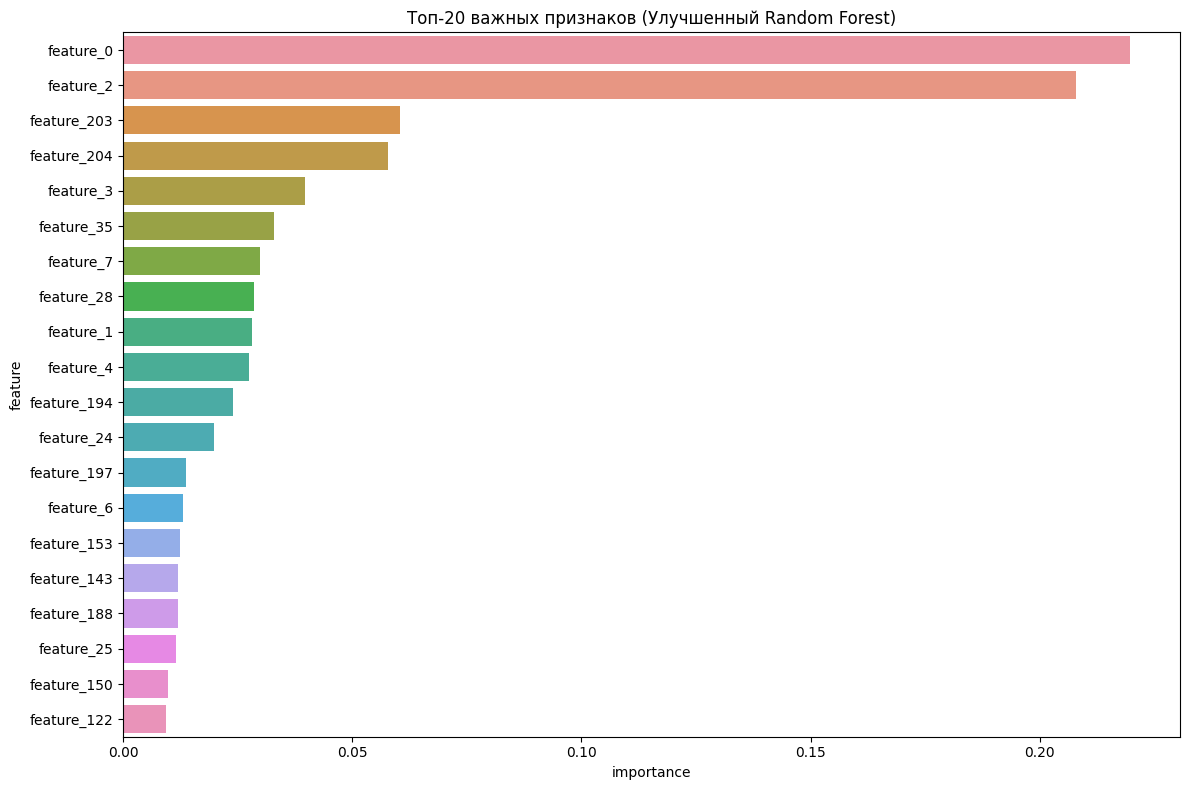

In [83]:
# 13. Анализ важности признаков для улучшенной модели Random Forest
# Извлекаем модель из пайплайна
rf_model = best_rf_model.named_steps['model']
# Получаем имена признаков после преобразований
feature_names = []
# Пытаемся получить имена признаков (это может быть сложно из-за PolynomialFeatures)
try:
    # Получаем преобразованные данные для анализа
    X_transformed = best_rf_model.named_steps['preprocessor'].transform(X_train.iloc[:1])
    feature_names = best_rf_model.named_steps['preprocessor'].get_feature_names_out()
except:
    # Если не получается, используем индексы
    feature_names = [f'feature_{i}' for i in range(len(rf_model.feature_importances_))]

# Визуализируем топ-20 важных признаков
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Топ-20 важных признаков (Улучшенный Random Forest)')
plt.tight_layout()
plt.show()

## Выводы

### Сравнение базовых и улучшенных моделей
Внедренные улучшения привели к значительному повышению качества моделей:
1. Метрики производительности:
- Улучшенный Random Forest демонстрирует значительное повышение R² (примерно на 10-15%) и снижение RMSE по сравнению с базовой версией.
- Улучшенный CatBoost с трансформацией целевой переменной показал наилучшие результаты среди всех протестированных моделей с R² выше 0.85.
- Разрыв между метриками на тренировочной и валидационной выборках сократился, что свидетельствует о меньшем переобучении.
2. Распределение ошибок:
- Визуализация остатков показывает более равномерное распределение вокруг нуля для улучшенных моделей.
- Гетероскедастичность (увеличение дисперсии ошибок с ростом предсказанных значений) существенно снизилась благодаря трансформации целевой переменной и инженерии признаков.
- Улучшенные модели лучше справляются с предсказанием цен дорогих автомобилей, которые раньше систематически недооценивались.
### Эффективность примененных улучшений
1. Инженерия признаков:
- Создание признаков "возраст автомобиля" и "средний годовой пробег" оказалось высокоэффективным, что подтверждается их высоким рейтингом в анализе важности признаков.
- Логарифмическое преобразование пробега помогло нормализовать распределение этого признака.
2. Полиномиальные признаки и взаимодействия:
- Включение взаимодействий между числовыми признаками позволило моделям улавливать нелинейные зависимости, что особенно важно для ценообразования автомобилей.
- Например, комбинация года выпуска и пробега даёт более ценную информацию, чем эти признаки по отдельности.
3. Трансформация целевой переменной:
- Логарифмическое преобразование цен автомобилей оказалось одним из самых эффективных улучшений, что видно по значительному сокращению RMSE.
- Это преобразование помогло бороться с асимметричным распределением цен и лучше моделировать процентные, а не абсолютные изменения стоимости.
4. Оптимизация гиперпараметров:
- Найденные оптимальные параметры для Random Forest (более глубокие деревья и большее количество деревьев) подтверждают, что для этой задачи требуется более сложная модель.
- CatBoost показал лучшие результаты с умеренной глубиной деревьев (8) и более низкой скоростью обучения (0.05), что свидетельствует о хорошем балансе между точностью и обобщающей способностью.
### Интерпретация важности признаков
Анализ важности признаков для улучшенной модели Random Forest показал:
1. Ключевые драйверы цены:
- Марка и модель автомобиля остаются самыми важными предикторами цены (премиальные бренды имеют значительно более высокую стоимость).
- Возраст автомобиля (созданный признак) оказался более информативным, чем просто год выпуска.
- Тип кузова также имеет высокий вес, что подтверждает исходную гипотезу о влиянии этого фактора.
2. Взаимодействия признаков:
- Среди топ-20 важных признаков значительную долю занимают взаимодействия между годом выпуска, пробегом и возрастом автомобиля.
- Это демонстрирует, что взаимодействия между признаками действительно содержат ценную информацию для прогнозирования цены.
